<a href="https://colab.research.google.com/github/srinehaaa/Srineha_160123771093_BDA_A2/blob/main/093_BDA_A2_Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q3 : Build a recommendation engine with spark with a dataset


In [1]:
!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Recommendation System") \
    .getOrCreate()

In [2]:
#data loading


import requests
import zipfile
import os

# Define the URL for the zip file and local file paths
zip_url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
zip_local_path = "ml-latest-small.zip"
extracted_dir = "ml-latest-small"
ratings_csv_path = os.path.join(extracted_dir, "ratings.csv")

# Download the zip file
print(f"Downloading {zip_url}...")
response = requests.get(zip_url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

with open(zip_local_path, "wb") as f:
    f.write(response.content)
print(f"File downloaded to {zip_local_path}")

# Unzip the file
print(f"Extracting {zip_local_path}...")
with zipfile.ZipFile(zip_local_path, 'r') as zip_ref:
    zip_ref.extractall('.') # Extract to the current directory
print(f"Extracted to directory {extracted_dir}")

# Read the CSV using Spark
df = spark.read.csv(
    ratings_csv_path,
    header=True,
    inferSchema=True
)

df.show(5)

File downloaded to ml-latest-small.zip
Extracting ml-latest-small.zip...
Extracted to directory ml-latest-small
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
+------+-------+------+---------+
only showing top 5 rows


In [3]:

df.printSchema()
print("Total rows:", df.count())

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

Total rows: 100836


In [4]:
#data exploration
df.printSchema()
print("Total rows:", df.count())

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

Total rows: 100836


In [5]:
# Unique users and movies
df.select("userId").distinct().count()
df.select("movieId").distinct().count()

9724

In [6]:
df.groupBy("rating").count().show()

+------+-----+
|rating|count|
+------+-----+
|   3.5|13136|
|   4.5| 8551|
|   2.5| 5550|
|   1.0| 2811|
|   4.0|26818|
|   0.5| 1370|
|   3.0|20047|
|   2.0| 7551|
|   1.5| 1791|
|   5.0|13211|
+------+-----+



Training the model

In [7]:
train, test = df.randomSplit([0.8, 0.2])

In [8]:

from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True
)

model = als.fit(train)


In [9]:

user_recs = model.recommendForAllUsers(5)
user_recs.show(5, truncate=False)

+------+--------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                   |
+------+--------------------------------------------------------------------------------------------------+
|1     |[{33649, 5.7997622}, {3379, 5.7375097}, {7121, 5.7055883}, {8477, 5.681712}, {3153, 5.5556335}]   |
|2     |[{170705, 4.9113817}, {131724, 4.891193}, {5666, 4.886717}, {33649, 4.781566}, {183897, 4.743085}]|
|3     |[{74754, 6.3687196}, {5919, 4.933239}, {6835, 4.929312}, {5746, 4.929312}, {5181, 4.929312}]      |
|4     |[{5915, 4.9738784}, {132333, 4.9526014}, {5490, 4.9526014}, {3851, 4.9113293}, {1733, 4.8546658}] |
|5     |[{8477, 4.9275465}, {3379, 4.9044895}, {33649, 4.809622}, {4642, 4.754374}, {25771, 4.7484374}]   |
+------+--------------------------------------------------------------------------------------------------+
only showing top 5 rows


In [10]:

movie_recs = model.recommendForAllItems(5)
movie_recs.show(5, truncate=False)

+-------+---------------------------------------------------------------------------------------+
|movieId|recommendations                                                                        |
+-------+---------------------------------------------------------------------------------------+
|1      |[{53, 5.3401036}, {99, 5.0938497}, {543, 5.0809536}, {35, 5.0762043}, {43, 4.946561}]  |
|3      |[{393, 4.815309}, {543, 4.608863}, {43, 4.556185}, {337, 4.4039297}, {53, 4.4009123}]  |
|5      |[{43, 4.348391}, {337, 4.2698584}, {393, 4.2400703}, {364, 4.070276}, {201, 4.0622377}]|
|6      |[{53, 5.289612}, {236, 4.8101544}, {276, 4.767992}, {515, 4.736956}, {371, 4.7341876}] |
|9      |[{43, 4.697177}, {243, 4.6955}, {543, 4.6718903}, {53, 4.4715962}, {492, 4.420594}]    |
+-------+---------------------------------------------------------------------------------------+
only showing top 5 rows


In [11]:
model.recommendForUserSubset(df.select("userId").distinct().limit(3), 5).show(truncate=False)


+------+-------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                  |
+------+-------------------------------------------------------------------------------------------------+
|471   |[{89904, 4.87761}, {2843, 4.729451}, {7121, 4.6738276}, {27611, 4.65981}, {158966, 4.608413}]    |
|463   |[{5075, 5.2160673}, {3379, 5.0846605}, {92535, 4.759981}, {86377, 4.7107534}, {177593, 4.703524}]|
|148   |[{3925, 4.6330647}, {33649, 4.6012597}, {7121, 4.51664}, {86781, 4.39873}, {93008, 4.39511}]     |
+------+-------------------------------------------------------------------------------------------------+



Analysis

In [12]:
df.groupBy("movieId") \
  .avg("rating") \
  .orderBy("avg(rating)", ascending=False) \
  .show(10)

+-------+-----------+
|movieId|avg(rating)|
+-------+-----------+
| 173963|        5.0|
|    633|        5.0|
| 152711|        5.0|
|    148|        5.0|
|   5513|        5.0|
|  67618|        5.0|
|     53|        5.0|
| 157775|        5.0|
| 113829|        5.0|
|  26350|        5.0|
+-------+-----------+
only showing top 10 rows


Visualizations

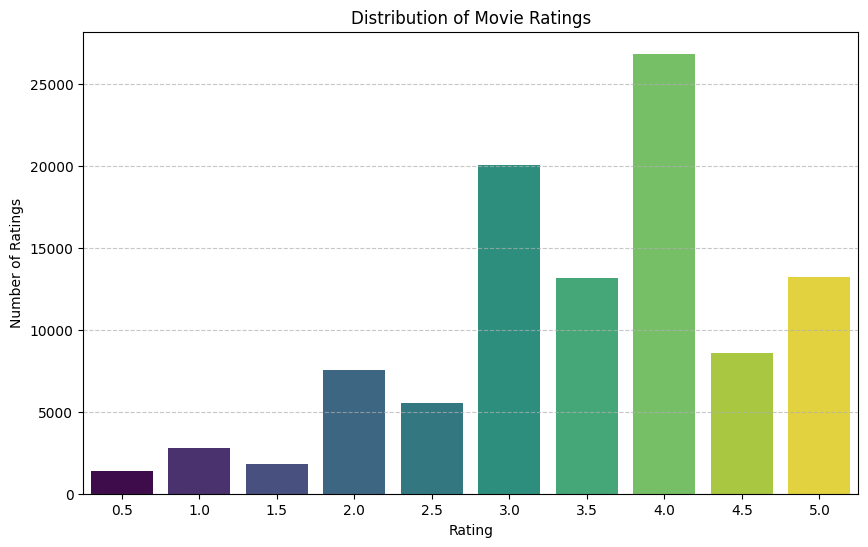

In [13]:

import matplotlib.pyplot as plt
import seaborn as sns

# Get the rating distribution
ratings_dist = df.groupBy("rating").count().orderBy("rating").toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(x='rating', y='count', data=ratings_dist, hue='rating', palette='viridis', legend=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
movies_csv_path = os.path.join(extracted_dir, "movies.csv")
movies_df = spark.read.csv(
    movies_csv_path,
    header=True,
    inferSchema=True
)
movies_df.show(5)

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


In [16]:
from pyspark.ml.evaluation import RegressionEvaluator

# Make predictions on the test data
predictions = model.transform(test)

# Evaluate the model using RMSE
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)

print(f"Root Mean Squared Error (RMSE) = {rmse}")

# Optionally, show some predictions
predictions.select("userId", "movieId", "rating", "prediction").show(5)

Root Mean Squared Error (RMSE) = 0.8758645949764757
+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|   148|   1197|   3.0| 3.7509117|
|   148|   4886|   3.0| 3.6453536|
|   148|  30816|   5.0| 2.8610606|
|   148|  31658|   4.0| 3.8328397|
|   148|  40629|   5.0| 3.0670335|
+------+-------+------+----------+
only showing top 5 rows


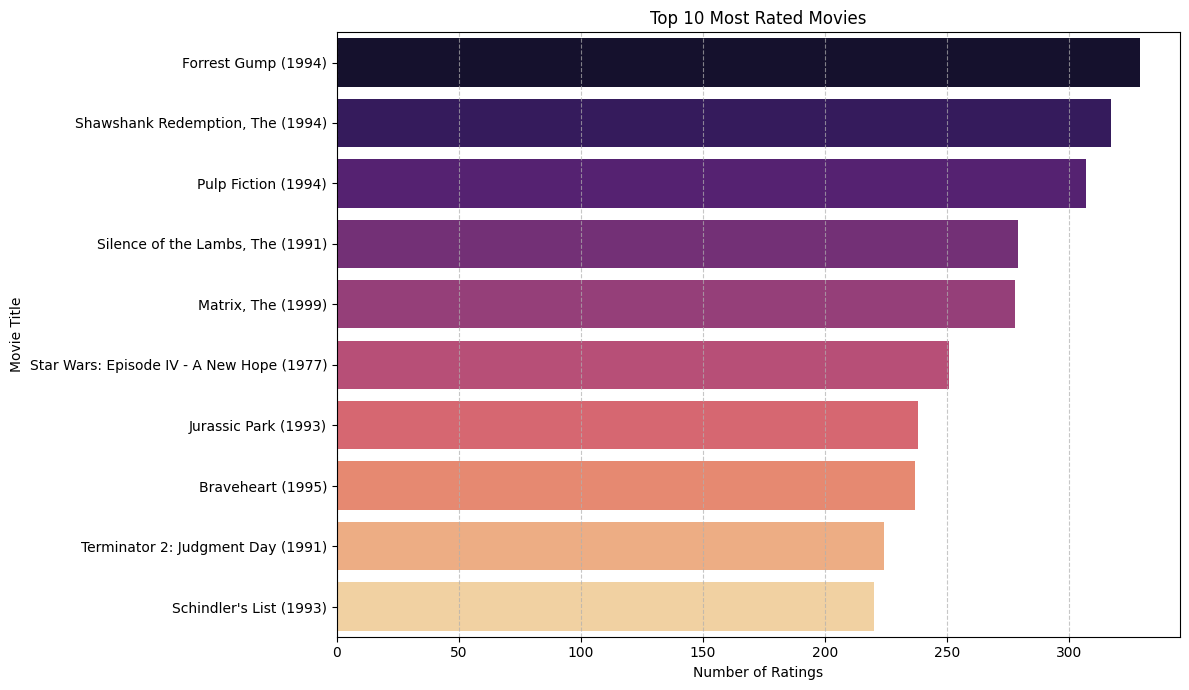

In [17]:

# Join ratings with movie titles and count ratings per movie
most_rated_movies = df.groupBy("movieId").count()
most_rated_movies = most_rated_movies.join(movies_df, "movieId", "inner") \
                                   .orderBy("count", ascending=False)

# Get top 10 most rated movies
top_10_rated_movies = most_rated_movies.limit(10).toPandas()

plt.figure(figsize=(12, 7))
sns.barplot(x='count', y='title', data=top_10_rated_movies, hue='title', palette='magma', legend=False)
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()